**Этот ноутбук является упражнением к курсу [«Введение в глубокое обучение»](https://www.kaggle.com/learn/intro-to-deep-learning). Вы можете обратиться к руководству по [этой ссылке](https://www.kaggle.com/ryanholbrook/deep-neural-networks).**

---


# Введение #

В руководстве мы увидели, как строить глубокие нейронные сети, складывая слои в стек внутри модели `Sequential`. Добавляя *функцию активации* после скрытых слоев, мы дали сети возможность изучать более сложные (нелинейные) зависимости в данных.

В этих упражнениях вы построите нейронную сеть с несколькими скрытыми слоями, а затем изучите некоторые функции активации, помимо ReLU. Запустите следующую ячейку, чтобы настроить всё необходимое!

In [2]:
import tensorflow as tf

# Настройка построения графиков
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
# Установка настроек по умолчанию для Matplotlib
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)

# Настройка системы обратной связи
# from learntools.core import binder
# binder.bind(globals())
# from learntools.deep_learning_intro.ex2 import *

В наборе данных *Concrete* (Бетон) ваша задача — предсказать прочность на сжатие бетона, изготовленного по различным рецептам.

Запустите следующую ячейку с кодом без изменений, чтобы загрузить набор данных.

In [3]:
import pandas as pd

# Загрузка данных о бетоне
concrete = pd.read_csv('./data/concrete.csv')
concrete.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


# 1) Размер входных данных (Input Shape) #

Целевая переменная для этой задачи — столбец `'CompressiveStrength'`. Остальные столбцы являются признаками, которые мы будем использовать на входе.

Каким будет размер входных данных (`input_shape`) для этого набора данных?

In [4]:
# ВАШ КОД ЗДЕСЬ
input_shape = [8]

# Проверка вашего ответа
# q_1.check()

In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_1.hint()
#q_1.solution()

# 2) Определение модели со скрытыми слоями #

Теперь создайте модель с тремя скрытыми слоями, каждый из которых имеет 512 блоков и активацию ReLU. Обязательно включите выходной слой из одного блока без функции активации, а также укажите `input_shape` в качестве аргумента первого слоя.

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

# ВАШ КОД ЗДЕСЬ
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=input_shape),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1),
])

# Проверка вашего ответа
# q_2.check()

c:\Users\iOlvik\Documents\1_Dev\Work\ML_training\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_2.hint()
#q_2.solution()

# 3) Слои активации #

Давайте немного изучим функции активации.

Обычный способ привязки функции активации к слою `Dense` — включить её в определение с помощью аргумента `activation`. Однако иногда вам может понадобиться поместить какой-то другой слой между слоем `Dense` и его функцией активации. (Мы увидим пример этого в 5-м уроке с *пакетной нормализацией*). В этом случае мы можем определить активацию в отдельном слое `Activation`, вот так:

```
layers.Dense(units=8),
layers.Activation('relu')
```

Это полностью эквивалентно обычному способу: `layers.Dense(units=8, activation='relu')`.

Перепишите следующую модель так, чтобы каждая активация находилась в отдельном слое `Activation`.

In [6]:
### ВАШ КОД ЗДЕСЬ: перепишите это, используя слои активации
model = keras.Sequential([
    layers.Dense(32, input_shape=[8]),
    layers.Activation('relu'),
    layers.Dense(32, activation='relu'),
    layers.Activation('relu'),
    layers.Dense(1),
])

# Проверка вашего ответа
# q_3.check()

In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_3.hint()
#q_3.solution()

# Дополнительно: Альтернативы ReLU #

Существует целое семейство вариантов активации `'relu'` — `'elu'`, `'selu'`, `'swish'` и другие, — все из которых можно использовать в Keras. Иногда одна активация работает лучше другой в конкретной задаче, поэтому вы можете поэкспериментировать с активациями при разработке модели. Активация ReLU, как правило, хорошо работает в большинстве задач, поэтому с неё удобно начинать.

Давайте посмотрим на графики некоторых из них. Измените активацию с `'relu'` на одну из вышеперечисленных. Затем запустите ячейку, чтобы увидеть график. (Смотрите [документацию](https://www.tensorflow.org/api_docs/python/tf/keras/activations) для получения новых идей.)

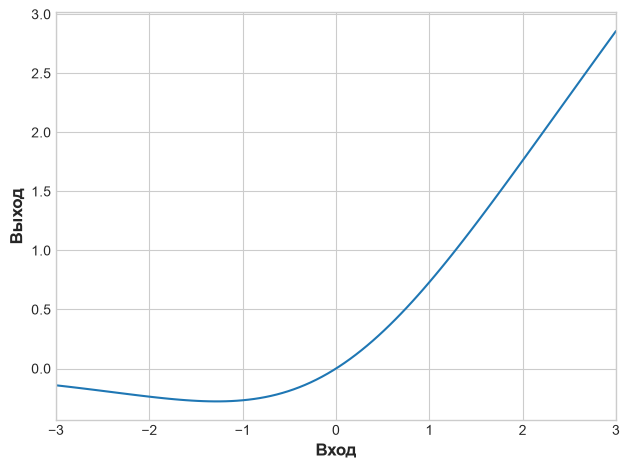

In [9]:
# ВАШ КОД ЗДЕСЬ: Замените 'relu' на 'elu', 'selu', 'swish'... или что-то другое
activation_layer = layers.Activation('swish')

x = tf.linspace(-3.0, 3.0, 100)
y = activation_layer(x) # после создания слой можно вызывать точно так же, как функцию

plt.figure(dpi=100)
plt.plot(x, y)
plt.xlim(-3, 3)
plt.xlabel("Вход")
plt.ylabel("Выход")
plt.show()

# Продолжайте движение! #

Теперь переходите к 3-му уроку и [**узнайте, как обучать нейронные сети**](https://www.kaggle.com/ryanholbrook/stochastic-gradient-descent) с помощью стохастического градиентного спуска.

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/intro-to-deep-learning/discussion), чтобы пообщаться с другими студентами.*